# Object Detection Using OpenCV

In [31]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [123]:
def mostrar_imagen(imagen, titulo = 'Imagen', cmap = 'gray'):
    mostrar_imagenes(imagenes=[imagen], titulos = [titulo], cmaps = [cmap])

def mostrar_imagenes(imagenes, titulos = None, cmaps = None):
    n = len(imagenes)
    if titulos is None:
        titulos = ['Imagen'] * n;

    if cmaps is None:
        cmaps = ['gray'] * n

    plt.figure(figsize=(5 * n, 5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(imagenes[i], cmap = cmaps[i])
        plt.title(titulos[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def mostrar_imagen_color(imagen, titulo = 'Imagen'):
    mostrar_imagen(cv.cvtColor(imagen, cv.COLOR_BGR2RGB), titulo, None)

def mostrar_imagenes_color(imagenes, titulos = None):
    mostrar_imagenes(
        imagenes = [cv.cvtColor(imagen, cv.COLOR_BGR2RGB) for imagen in imagenes],
        titulos = titulos,
        cmaps = [None] * len(imagenes)
    )

In [412]:
car2 = cv.imread('./imagenes/object_detection/car1.png')
car2_gray = cv.cvtColor(car2, cv.COLOR_BGR2GRAY)

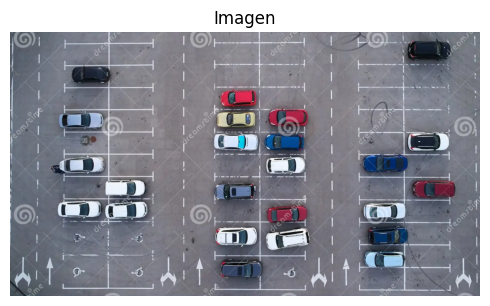

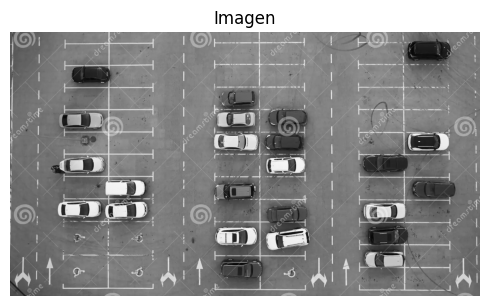

In [413]:
mostrar_imagen_color(car2)
mostrar_imagen(car2_gray)

In [414]:
blur = cv.GaussianBlur(car2_gray, (5, 5), 0)

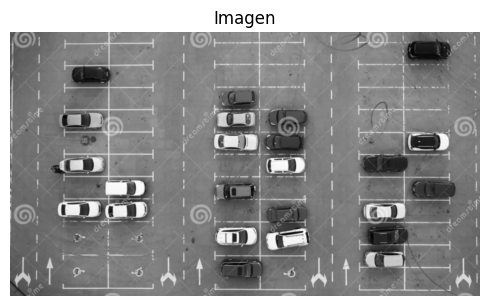

In [415]:
mostrar_imagen(blur)

In [416]:
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
contrast = clahe.apply(blur)

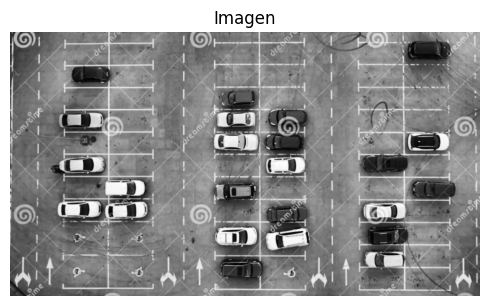

In [417]:
mostrar_imagen(contrast)

In [340]:
otsu_threshold, otsu01 = cv.threshold( contrast, 0, 255, cv.THRESH_OTSU)

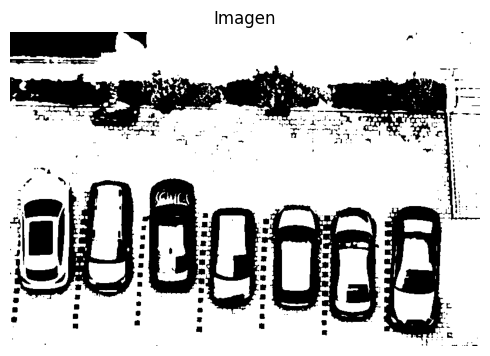

In [341]:
mostrar_imagen(otsu01)

In [342]:
edges = cv.Canny(otsu01, 150, 350)

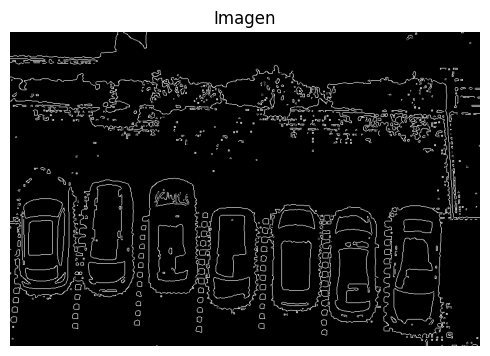

In [343]:
mostrar_imagen(edges)

In [351]:
kernel = np.ones((3, 3), np.uint8)
dilated = cv.dilate(edges, kernel, iterations=2)

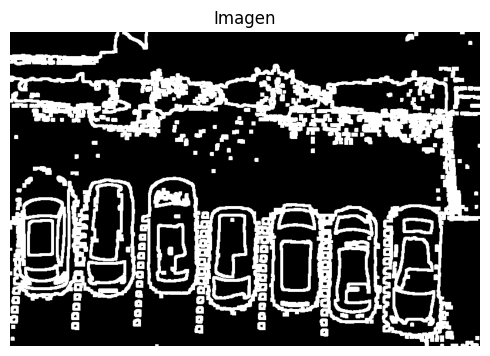

In [352]:
mostrar_imagen(dilated)

In [353]:
eroded = cv.erode(dilated, kernel, iterations = 1)

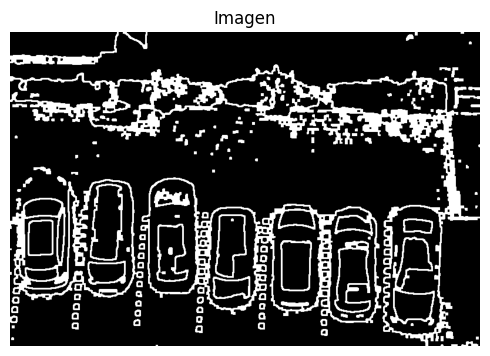

In [354]:
mostrar_imagen(eroded)

In [355]:
contours, _ = cv.findContours(eroded, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

In [362]:
car2_canny = car2.copy()
for cnt in contours:
    area = cv.contourArea(cnt)
    if 400 < area < 15000:  # Ajusta estos valores según la escala de tus imágenes
        x, y, w, h = cv.boundingRect(cnt)
        aspect_ratio = w / h
        #if 0.7 < aspect_ratio < 2.5:  # Rectángulos (autos vistos desde arriba)
        cv.rectangle(car2_canny, (x, y), (x + w, y + h), (0, 255, 0), 2)

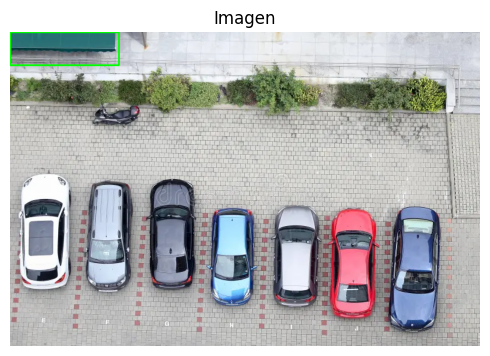

In [363]:
mostrar_imagen_color(car2_canny)

## Haar Cascade

In [365]:
car_cascade = cv.CascadeClassifier('./Actividad-3/cars.xml')

In [418]:
cars = car_cascade.detectMultiScale(contrast, scaleFactor=1.1, minNeighbors=1, minSize=(20, 20))

In [419]:
car2_haar = car2.copy()
for (x, y, w, h) in cars:
    cv.rectangle(car2_haar, (x, y), (x + w, y + h), (0, 255, 0), 2)

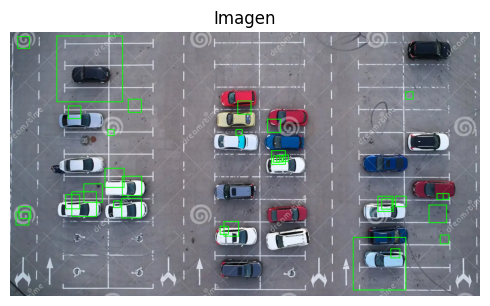

In [420]:
mostrar_imagen_color(car2_haar)

## 